In [ ]:
#Install and Import Dependencies
!pip3 install torch torchvision

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 103.1 MB/s eta 0:00:00


In [ ]:
import torch
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import cv2

Load Model (Practice Model) From YOLO

In [ ]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv5n model
model = YOLO("yolov5n.pt")

# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)
results = model("https://ultralytics.com/images/zidane.jpg")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

YOLOv5n summary: 153 layers, 2,654,816 parameters, 0 gradients, 7.8 GFLOPs
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0

In [ ]:
img = cv2.imread("./zidane.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

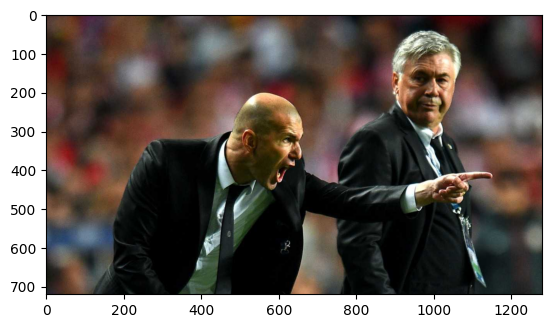

In [ ]:
plt.imshow(img_rgb)

In [ ]:
results = model(img_rgb)


0: 384x640 4 persons, 125.8ms
Speed: 3.6ms preprocess, 125.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


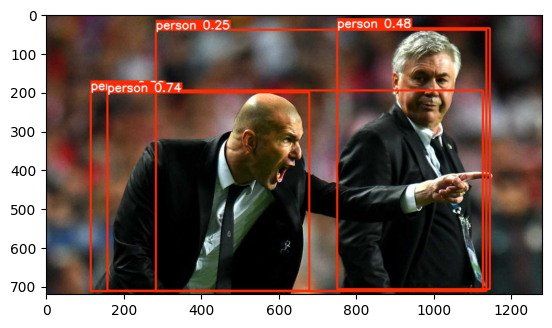

In [ ]:
result_img = results[0].plot()
plt.imshow(result_img)

In [ ]:
traffic_img = cv2.imread("/content/drive/MyDrive/Drowsiness_detector_model/traffic.jpg")
img_rgb = cv2.cvtColor(traffic_img, cv2.COLOR_BGR2RGB)

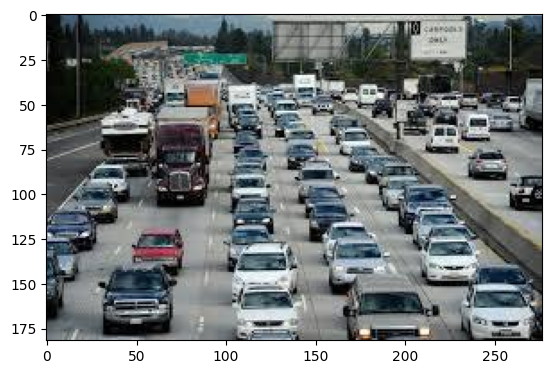

In [ ]:
plt.imshow(img_rgb)

In [ ]:
results = model(img_rgb)


0: 448x640 10 cars, 13 buss, 7 trucks, 161.7ms
Speed: 5.2ms preprocess, 161.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


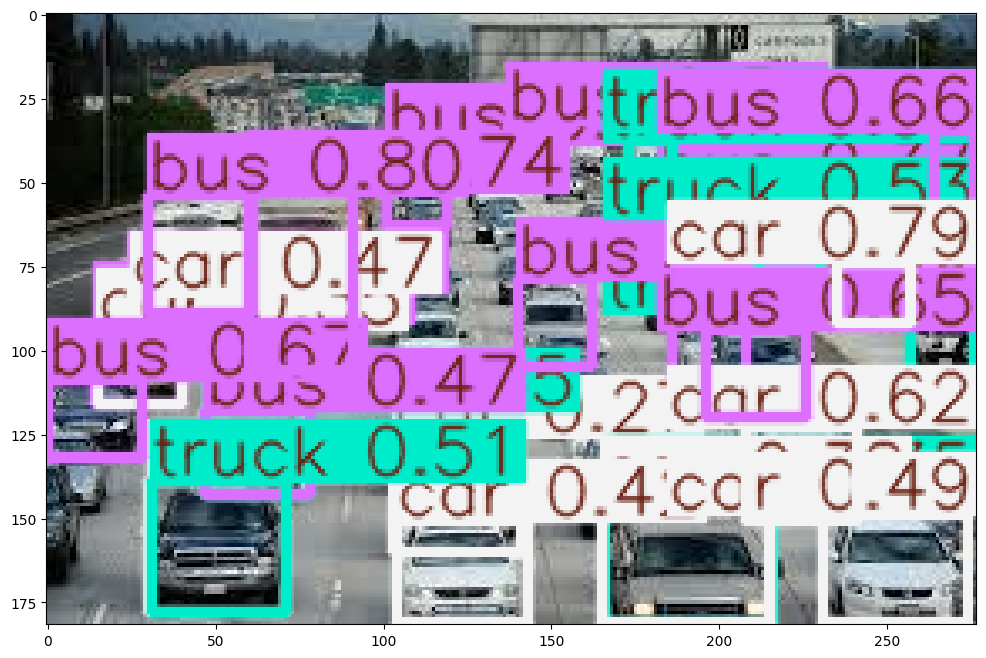

In [ ]:
result_img = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(result_img)

#Above is the basic model provided by YOLO themselves, I trained a basic Yolo5n model using their own dataset and as results show above, the model is great at object detection given the provided data set is great.
#Now let's try real time detections.


In [ ]:
video_capture = cv2.VideoCapture(2) #0, 1 or 2 depending on your laptop
while video_capture.isOpened():
    ret, frame = video_capture.read()

    results = model(frame) #pass in the frames for detection
    detected_frame = results[0].plot()
    cv2.imshow('YOLO', frame)

    if cv2.waitKey(20) & 0xFF == 27: #if esc is pressed, then video environment will stop after 20 ms
        break

video_capture.release()
cv2.destroyAllWindows()
#Above code will not run in my jupyter notebook environment, need to run it locally but it works!

#Now let's train a model for our drowsiness detector using Yolov8 nano

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Feb  3 21:29:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   36C    P0             73W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Ensuring GPU is connected for our custom model training

Dataset Information:


*   Total Images: 9,694

*   Training Set: 6k images

*   Validation Set: 1.9k images

*   Testing Set: 1.8k images

*   Classes: asleep, Attentive eye, close, closed, Drowsy eye, eye closed, no Yawn, open, open mouth


mAP@50 = 80.5%

Precision = 81.6%

Recall = 72.1 %

154 Downloads



Notes on YOLO8:
YOLOv8 was released by Ultralytics on January 10, 2023, offering cutting-edge performance in terms of accuracy and speed. Building upon the advancements of previous YOLO versions, YOLOv8 introduced new features and optimizations that make it an ideal choice for various object detection tasks in a wide range of applications.

Choosing YOLO8 for better performance and accuracy over YOLO5 models. Some of the models key features are as follows:

* Advanced Backbone and Neck Architectures: YOLOv8 employs state-of-the-art backbone and neck architectures, resulting in improved feature extraction and object detection performance.

* Anchor-free Split Ultralytics Head: YOLOv8 adopts an anchor-free split Ultralytics head, which contributes to better accuracy and a more efficient detection process compared to anchor-based approaches.

* Optimized Accuracy-Speed Tradeoff: With a focus on maintaining an optimal balance between accuracy and speed, YOLOv8 is suitable for real-time object detection tasks in diverse application areas.

* Variety of Pretrained Models: YOLOv8 offers a range of pretrained models to cater to various tasks and performance requirements, making it easier to find the right model for your specific use case.(calssification, segmentation, etc)


YOLO automatically applies:

* Flipping, rotation & scaling

* Color Adjustments (HSV)

* Mosaic augmentation (combines 4 images)

Consider its better architecture and capability to detect objects more accurately and more faster, we chose to train a YOLO 8 for our project for prototype one. It also balances better in terms of speed & accuracy compared to Yolo v5.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Model Architecture
Model: YOLOv8 Nano (Pre-trained)

Parameters: 3,011,433

Layers: 130

Optimizer: AdamW
### Training Hyperparameters

epochs = 50

image_size = 640


In [ ]:
from ultralytics import YOLO
#importing again since runtime was changed to GPU
# Load a COCO-pretrained YOLO11n model
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
import zipfile
import os

zip_file_path = '/content/Archive 4.31.42 PM.zip'
output_dir = '/content/dataset' # location of unzipped files

# Create an output directory and if one exists exist_ok bypasses the error
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref: #opening zip file in read mode
    zip_ref.extractall(output_dir)

print(f"File '{zip_file_path}' unzipped to '{output_dir}'")

File '/content/Archive 4.31.42 PM.zip' unzipped to '/content/dataset'


In [8]:
results = model.train(data="/content/dataset/data.yaml", epochs=50, imgsz=640, batch=-1, device=0)
#setting batch size to -1 for yolo to auto configure the best batch size for epochs the current GPU, setting device = 0 to use GPU

Ultralytics 8.4.11 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA H100 80GB HBM3, 81224MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

#Training Results

Final Metrics:

mAP@0.5 = 78.4%

Precision = 76.1%

Recall = 72.0%

Box Loss (val) = 1.514

Class Loss (val) = 1.026

Strengths:
1. Strong overall accuracy (79-81% mAP@0.5)
2. Great convergence (Losses decreased steadily without overfitting)
3. Good precision (76%) - few false positives
4. No overfitting

Areas for improvement(s):
1. Recall could be higher (72%) - missing some detections
2. Yawn Detection (only 38% detection rate)
3. Class imbalance affecting performance

Next Steps:
- Improve yawn class detection
- Improve recall
- Try a YOLO 11 model maybe?


In [9]:
import shutil
import os

output_filename = 'runs'
shutil.make_archive(output_filename, 'zip', '/content/runs')
print(f"Folder '/content/runs' has been zipped to '{output_filename}.zip'")

Folder '/content/runs' has been zipped to 'runs.zip'


In [10]:
from google.colab import files

files.download('runs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dowloaded the model and other output files locally using the above code. Now to test it out using openCV:

(Below code will not run in notebook environment, has to be run locally):

In [ ]:
import cv2

# Loading trained model (link your run eg. (windows) C:\\users\\folder\\best.pt)
model = YOLO('/Users/nrpatel370/Desktop/runs/detect/train/weights/best.pt')


import cv2

# Use AVFoundation backend on macOS (for windows its different syntax)
video_capture = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)

if not video_capture.isOpened():
    print("Could not open camera")
    exit()

while True:
    ret, frame = video_capture.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Run YOLO inference
    results = model(frame)

    # Draw bounding boxes on frame
    detected_frame = results[0].plot()

    # Show the detected object(s)
    cv2.imshow('YOLO', detected_frame)

    # ESC key to exit
    if cv2.waitKey(1) & 0xFF == 27:
        break

video_capture.release()
cv2.destroyAllWindows()
